## Uninformed Searches: DFS, BFS, and UCS with Python-Graphviz

##### DFS, BFS, and UCS are uninformed search algorithms used to traverse graphs or trees to find a goal. They are called "uninformed" because they only know the structure of the map and don't have extra hints (heuristics) about how close they are to the finish.

Depth-First Search (DFS) goes "all in" on one direction. It explores as far as possible down a branch before backtracking.

- **Strategy**: Explore the deepest node first.
- **Data Structure**: Uses a Stack (LIFO - Last In, First Out).
- **Pros**: Low memory usage because it only needs to remember the current path.
- **Cons**: Not guaranteed to find the shortest path and can get stuck in infinite loops in large graphs.

Breadth-First Search (BFS) explores "layer by layer." It visits all neighbors of the starting point, then all of their neighbors, and so on.
- **Strategy**: Explore the shallowest node first.
- **Data Structure**: Uses a Queue (FIFO - First In, First Out).
- **Pros**: Guaranteed to find the shortest path in unweighted graphs (where every step costs the same).
- **Cons**: High memory usage because it must store every node at the current "level".

Uniform-Cost Search (UCS) is the "smart" version of BFS for weighted graphs (where some paths are more expensive than others).
- **Strategy**: Always expand the node with the lowest cumulative path cost.
- **Data Structure**: Uses a Priority Queue (Min-Heap).
- **Pros**: Guaranteed to find the optimal (cheapest) path, even when step costs vary.
- **Cons**: Can be slow as it explores in every direction to ensure it hasn't missed a cheaper route.

### Part 1: Import the libraries

The graphviz library is a tool that allows us to draw graphs or trees dynamically. This is useful for visualizing the search trees and graphs.

In [1]:
import graphviz
from graphviz import Graph, Digraph

### Part 2: Draw a Graph

In [2]:
from graphviz import Graph, Digraph

def draw_graph(nodes, edges, fill_color=None, graph_type="undirected", rankdir="LR"):
    """
    Draws a graph from a list of nodes and a dictionary of edges.
    
    Args:
        nodes (list): A list of node identifiers.
        edges (dict): A dictionary where keys are starting nodes and 
                     values are lists of ending nodes (e.g., {'A': ['B', 'C']}).
        fill_color (str): The color of the nodes.
        type (str): "Undirected" or "Directed".
        
    Raises:
        ValueError: If a node in the edges dictionary is not present in the nodes list.
    """

    if graph_type == "undirected":
        graph = Graph(format='png')
    elif graph_type == "directed":
        graph = Digraph(format='png')
    else:
        raise ValueError("Invalid graph type. Use 'Undirected' or 'Directed'.")
    
    graph.attr(rankdir=rankdir)

    # Add nodes to the graph
    for node in nodes:
        graph.node(node, style='filled', fillcolor=fill_color)

    # Validate and add edges
    for start_node, end_nodes in edges.items():
        # Check if the starting node exists
        if start_node not in nodes:
            raise ValueError(f"Error: Node '{start_node}' found in edges but not in nodes list.")
        
        for end_node in end_nodes:
            # Check if the destination node exists
            if end_node not in nodes:
                raise ValueError(f"Error: Node '{end_node}' found in edges but not in nodes list.")
            
            graph.edge(start_node, end_node)

    return graph


**2.1. Undirected Graph**

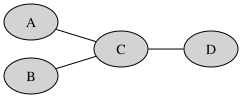

In [3]:
# Undirected graph
nodes = ['A', 'B', 'C', 'D']
edges = {'A': ['B'], 'B': ['C'], 'A': ['C'], 'C': ['D']}
my_graph1 = draw_graph(nodes, edges, graph_type="undirected", rankdir="LR")
my_graph1.render('graph-1', view=False)
my_graph1

**2.3. Directed Graph**

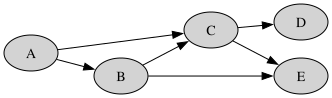

In [4]:
# Directed graph
nodes = ['A', 'B', 'C', 'D', 'E']
edges = {'A': ['B', 'C'], 'B': ['C', 'E'], 'C': ['D', 'E']}
my_graph2 = draw_graph(nodes, edges, graph_type="directed", rankdir="LR")
my_graph2.render('graph-2', view=False)
my_graph2

**2.4. Undirected Graph with filled color**

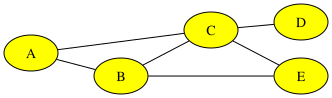

In [5]:
# Undirected graph with yellow nodes
nodes = ['A', 'B', 'C', 'D', 'E']
edges = {'A': ['B', 'C'], 'B': ['C', 'E'], 'C': ['D', 'E']}
my_graph3 = draw_graph(nodes, edges, fill_color='yellow', graph_type="undirected", rankdir="LR")
my_graph3.render('graph-3', view=False)
my_graph3

**2.5. Directed Graph with filled color**

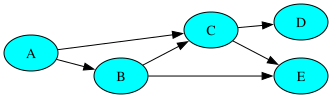

In [6]:
# Directed graph with blue nodes
nodes = ['A', 'B', 'C', 'D', 'E']
edges = {'A': ['B', 'C'], 'B': ['C', 'E'], 'C': ['D', 'E']}
my_graph4 = draw_graph(nodes, edges, fill_color='cyan', graph_type="directed", rankdir="LR")
my_graph4.render('graph-4', view=False)
my_graph4

In [7]:
def draw_tree(nodes, edges, fill_color=None, tree_type="undirected", rankdir=None):
    """
    Draws a tree from a list of nodes and a dictionary of edges.
    
    Args:
        nodes (list): A list of node identifiers.
        edges (dict): A dictionary where keys are parent nodes and 
                     values are lists of child nodes.
        fill_color (str): Optional color to fill the nodes.
        tree_type (str): "undirected" or "directed".
        rankdir (str): Direction of the tree layout (e.g., 'LR', 'TB').
    """
    if tree_type == "undirected":
        tree = Graph('Tree', format='png')
    elif tree_type == "directed":
        tree = Digraph('Tree', format='png')
    else:
        raise ValueError("Invalid tree type. Use 'undirected' or 'directed'.")

    # Set layout direction (LR = Left to Right, TB = Top to Bottom)
    tree.attr(rankdir=rankdir)

    # Add nodes to the tree with optional styling
    for node in nodes:
        if fill_color:
            tree.node(node, style='filled', fillcolor=fill_color)
        else:
            tree.node(node)

    # Validate and add edges from the dictionary
    for parent, children in edges.items():
        # Check if the parent node exists in the node list
        if parent not in nodes:
            raise ValueError(f"Error: Node '{parent}' found in edges but not in nodes list.") [cite: 8]
        
        for child in children:
            # Check if the child node exists in the node list
            if child not in nodes:
                raise ValueError(f"Error: Node '{child}' found in edges but not in nodes list.") [cite: 8]
            
            tree.edge(parent, child)

    return tree

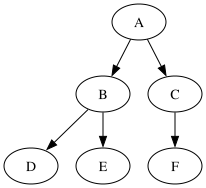

In [8]:
# Draw a tree
tree_nodes = ['A', 'B', 'C', 'D', 'E', 'F']
tree_edges = {'A': ['B', 'C'], 'B': ['D', 'E'], 'C': ['F']}

tree1 = draw_tree(tree_nodes, tree_edges, tree_type="directed")
tree1.render('tree-4', view=False)
tree1

### Part 3: Uninformed Searches

In [9]:
from collections import deque
from IPython.display import display, clear_output
import time

**3.1. Depth-First Search (DFS)**


In [10]:
# 3.1. DFS Function with Target Logic
def dfs(nodes, edges, current, target_node, visited, steps):
    visited.append(current)
    
    color = 'lightgreen' if current == target_node else 'yellow'
    step_graph = draw_tree(nodes, edges, tree_type="directed")
    for n in visited:
        step_graph.node(n, style='filled', fillcolor='lightgreen' if n == target_node else 'lightgrey')
    step_graph.node(current, style='filled', fillcolor=color)
    steps.append(step_graph)

    if current == target_node:
        return True

    if current in edges:
        for neighbor in edges[current]:
            if neighbor not in visited:
                if dfs(nodes, edges, neighbor, target_node, visited, steps):
                    return True
    return False

def run_dfs(nodes, edges, start, target_node=None):
    visited = []
    steps = []
    dfs(nodes, edges, start, target_node, visited, steps)
    return steps

# 4. Animation Helper
def animate(steps, delay=1):
    for step in steps:
        clear_output(wait=True)
        display(step)
        time.sleep(delay)

**3.2. Breadth-First Search (BFS)**

In [11]:
# 2. BFS Function with Target Logic
def bfs(nodes, edges, start, target_node=None):
    visited = []
    queue = deque([start])
    steps = []
    found = False

    while queue:
        current = queue.popleft()
        if current not in visited:
            visited.append(current)
            
            # Determine color: Green if target found, Yellow for current, Lightblue for visited
            color = 'lightgreen' if current == target_node else 'yellow'
            steps.append(draw_tree(nodes, edges, fill_color=None, tree_type="directed")) # Base tree
            
            # Re-draw the step with specific highlights (internal to animation logic)
            step_graph = draw_tree(nodes, edges, tree_type="directed")
            for n in visited:
                step_graph.node(n, style='filled', fillcolor='lightblue')
            step_graph.node(current, style='filled', fillcolor=color)
            steps.append(step_graph)

            if current == target_node:
                found = True
                break
            
            # Add neighbors to queue
            if current in edges:
                for neighbor in edges[current]:
                    queue.append(neighbor)
    return steps

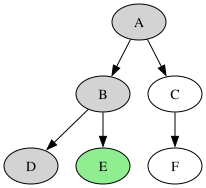

In [12]:
# Execute Animations
dfs_steps = run_dfs(tree_nodes, tree_edges, 'A', target_node='E')
animate(dfs_steps)

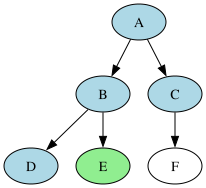

In [13]:
bfs_steps = bfs(tree_nodes, tree_edges, 'A', target_node='E')
animate(bfs_steps)

**3.3. Uniform-Cost Search (UCS)**

In [14]:
import heapq

In [15]:
from graphviz import Digraph

def draw_weighted_tree(nodes, edges, weights=None, node_labels=None, fill_color=None, rankdir="TB"):
    tree = Digraph(format='png')
    tree.attr(rankdir=rankdir, nodesep='0.5', ranksep='0.8')
    
    # Standardize node appearance
    tree.node_attr.update(shape='circle', style='filled', fontname='Helvetica', fixedsize='true', width='0.6')

    for node in nodes:
        label = node_labels.get(node, node) if node_labels else node
        color = fill_color if fill_color else 'white'
        tree.node(node, label=label, fillcolor=color)

    for parent, children in edges.items():
        for child in children:
            edge_label = str(weights.get((parent, child), "")) if weights else ""
            tree.edge(parent, child, label=edge_label)

    return tree

In [16]:
generated_tree = {
    'label': 'A', 'cost': 0, 'children': [
        {'label': 'B', 'cost': 1, 'children': [
            {'label': 'D', 'cost': 5, 'children': [
                {'label': 'G', 'cost': 7, 'children': [
                    {'label': 'H', 'cost': 9, 'children': []}
                ]}
            ]},
            {'label': 'E', 'cost': 6, 'children': [
                {'label': 'I', 'cost': 8, 'children': []},
                {'label': 'J', 'cost': 5, 'children': []}
            ]}
        ]},
        {'label': 'C', 'cost': 2, 'children': [
            {'label': 'F', 'cost': 1, 'children': []}
        ]}
    ]
}

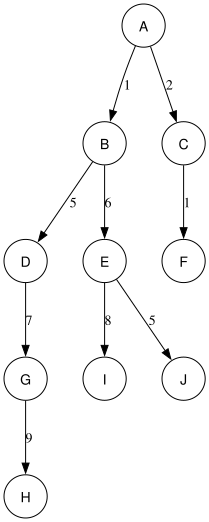

In [17]:
# Convert nested tree into nodes, edges, weights
nodes = []
edges = {}
weights = {}

def traverse(node):
    label = node['label']
    nodes.append(label)

    children = node.get('children', [])
    edges[label] = []

    for child in children:
        child_label = child['label']

        edges[label].append(child_label)

        # Use child cost as edge weight
        weights[(label, child_label)] = child['cost']

        traverse(child)

traverse(generated_tree)
# Draw tree
weighted_tree = draw_weighted_tree(nodes, edges, weights=weights, rankdir="TB")

# Save and view
weighted_tree.render("weighted_tree", view=False)
weighted_tree

In [18]:
# Uniform Cost Search
def ucs_algorithm(root, goal, on_visit=None):
    # (total_cost, node)
    queue = [(0, root)]
    visited_cost = {}

    while queue:
        # Priority Queue behavior
        queue.sort(key=lambda x: x[0])
        cost, node = queue.pop(0)
        node_label = node['label']

        # Skip if already visited with lower cost
        if node_label in visited_cost and visited_cost[node_label] <= cost:
            continue

        visited_cost[node_label] = cost
        # Callback for animation / visualization
        if on_visit:
            on_visit(node, cost, visited_cost)
        else:
            print(f"Visiting node: {node_label}, total cost: {cost}")
            

        # Goal check
        if node_label == goal:
            print(f"\nGoal found: {goal}")
            print(f"Total path cost: {cost}")
            return cost
            
        # Expand children
        for child in node['children']:
            # Child edge cost
            edge_cost = child['cost']
            new_cost = cost + edge_cost
            queue.append((new_cost, child))

    print("Goal not found.")
    return None

In [19]:
ucs_algorithm(generated_tree, goal='J')

Visiting node: A, total cost: 0
Visiting node: B, total cost: 1
Visiting node: C, total cost: 2
Visiting node: F, total cost: 3
Visiting node: D, total cost: 6
Visiting node: E, total cost: 7
Visiting node: J, total cost: 12

Goal found: J
Total path cost: 12


12

In [20]:
from IPython.display import display

def generate_frames(root, goal):

    frames = []

    def capture_frame(current_node, cost, visited):
        dot = graphviz.Digraph()
        dot.attr(rankdir='TB')

        def draw(node, parent=None):
            node_id = str(id(node))
            # Node label
            label = f"{node['label']}\nCost={node['cost']}"

            # Coloring
            if node['label'] == goal and id(node) == id(current_node):
                fillcolor = 'green'

            elif id(node) == id(current_node):
                fillcolor = 'lightblue'

            elif node['label'] in visited:
                fillcolor = 'lightgray'

            else:
                fillcolor = 'white'

            dot.node(node_id, label=label, style='filled', 
            fillcolor=fillcolor, shape='circle')

            if parent:
                # Find edge cost
                edge_cost = node['cost']
                dot.edge(parent, node_id, label=str(edge_cost))

            for child in node['children']:
                draw(child, node_id)

        draw(root)
        frames.append(dot)

    ucs_algorithm(root, goal, on_visit=capture_frame)

    return frames

In [26]:
import imageio.v2 as imageio
import os
from IPython.display import Image, display

def export_gif(
    frames,
    gif_name="ucs_animation.gif",
    seconds_per_frame=1,
    fps=10
):

    frame_files = []

    # Render PNG frames
    for i, frame in enumerate(frames):

        filename = f"frame_{i}"
        frame.render(filename=filename, format="png", cleanup=True)
        frame_files.append(f"{filename}.png")

    images = []

    # Number of repeated frames
    repeat_count = seconds_per_frame * fps

    for f in frame_files:
        if os.path.exists(f):
            img = imageio.imread(f)
            # Duplicate frame for pause effect
            for _ in range(repeat_count):
                images.append(img)

    print("Frames:", len(frames))
    print("GIF Frames:", len(images))

    # Create smooth GIF
    imageio.mimsave(gif_name, images, fps=fps, loop=0)

    # Display GIF
    display(Image(filename=gif_name))

    # Cleanup PNG files
    for f in frame_files:
        if os.path.exists(f):
            os.remove(f)


Goal found: J
Total path cost: 12
Frames: 7
GIF Frames: 70


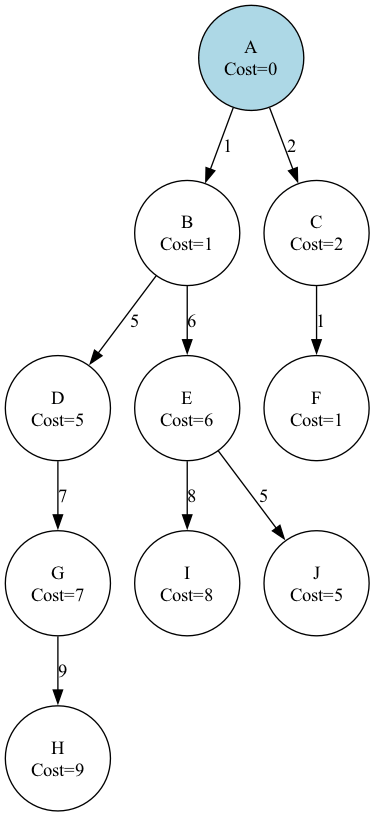

In [28]:
frames = generate_frames(generated_tree, goal='J')
# Export and display GIF
export_gif(frames, gif_name="ucs_animation.gif", seconds_per_frame=1, fps=10)